# EEG Motor İmgelem — Derin Öğrenme (v6)
## PhysioNet EEG Motor Movement/Imagery Dataset

**Veri seti:** https://www.physionet.org/content/eegmmidb/1.0.0/  
**Görev:** Sol el (T1) vs Sağ el (T2) motor imgelem sınıflandırması  
**Yöntem:** Ham EEG → EEGNet / ShallowConvNet / DeepConvNet + PCA (embedding)

### Klasik ML (v5) ile Fark
| Özellik | v5 (Klasik ML) | v6 (Derin Öğrenme) |
|---|---|---|
| Özellik çıkarma | FBCSP (elle tasarlanmış) | Yok — CNN kendisi öğrenir |
| Giriş | 24 CSP özelliği | Ham sinyal (64 × 480) |
| Boyut azaltma | CSP → PCA | Embedding (feature map) → PCA |
| Framework | scikit-learn | PyTorch |

## 1. Kütüphane Kurulumu ve İthalat

In [7]:
# !pip install mne torch scikit-learn numpy pandas matplotlib seaborn

In [8]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

mne.set_log_level('WARNING')
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"PyTorch : {torch.__version__}")
print(f"MNE     : {mne.__version__}")
print(f"Kullanılan Cihaz: {DEVICE}")

PyTorch : 2.11.0
MNE     : 1.12.1
Kullanılan Cihaz: mps


## 2. Parametreler

In [9]:
DATA_DIR     = '../physioNet_Dataset'
N_SUBJECTS   = 40
IMAGERY_RUNS = ['R03', 'R04', 'R07', 'R08', 'R11', 'R12']  # ~180 epoch/denek

# Tek bant filtresi — CNN bant özelliklerini kendisi öğrenir
L_FREQ, H_FREQ = 0.5, 40.0   # Geniş bant: CNN için daha iyi

TMIN, TMAX = 1.0, 4.0         # Saf imgelem penceresi

# Eğitim parametreleri
N_FOLDS    = 5
BATCH_SIZE = 16
N_EPOCHS   = 80    # Maksimum eğitim epoch sayısı
LR         = 1e-3
PATIENCE   = 12    # Early stopping

print(f"Denek       : {N_SUBJECTS}")
print(f"Koşu/denek  : {len(IMAGERY_RUNS)} → ~{len(IMAGERY_RUNS)*30} epoch/denek")
print(f"Filtre      : {L_FREQ}-{H_FREQ} Hz (geniş bant)")
print(f"Epoch       : {TMIN}-{TMAX}s | {N_FOLDS}-fold CV")
print(f"Eğitim      : max {N_EPOCHS} epoch | LR={LR} | Patience={PATIENCE}")

Denek       : 40
Koşu/denek  : 6 → ~180 epoch/denek
Filtre      : 0.5-40.0 Hz (geniş bant)
Epoch       : 1.0-4.0s | 5-fold CV
Eğitim      : max 80 epoch | LR=0.001 | Patience=12


## 3. Veri Yükleme

Derin öğrenmede FBCSP uygulanmaz — ham EEG sinyali doğrudan CNN'e verilir.
Ön işleme: EDF yükle → kanal normalizasyonu → epoch oluştur.

In [10]:
def load_subject_raw(subject_id, runs, data_dir, l_freq, h_freq, tmin, tmax):
    """
    Ham EEG epoch'larını döndürür: (n_epochs, n_channels, n_times)
    CNN için özellik çıkarımı yapılmaz.
    """
    sub  = f'S{subject_id:03d}'
    raws = []
    for run in runs:
        path = f'{data_dir}/{sub}/{sub}{run}.edf'
        try:
            raws.append(mne.io.read_raw_edf(path, preload=True, verbose=False))
        except FileNotFoundError:
            pass
    if not raws:
        return None, None

    raw = mne.concatenate_raws(raws)
    raw.rename_channels({ch: ch.rstrip('.').upper() for ch in raw.ch_names})
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'),
                    on_missing='ignore')
    raw.pick('eeg')
    raw.filter(l_freq, h_freq, fir_design='firwin', verbose=False)
    raw.notch_filter(60, verbose=False)

    events, ann_id = mne.events_from_annotations(raw, verbose=False)
    ev_id = {k: v for k, v in ann_id.items() if k in ['T1', 'T2']}
    if not ev_id:
        return None, None

    ep = mne.Epochs(raw, events, ev_id, tmin=tmin, tmax=tmax,
                    proj=True, picks='eeg', baseline=None,
                    preload=True, verbose=False)
    ep.drop_bad(verbose=False)

    X = ep.get_data().astype(np.float32)   # (n_ep, 64, n_times)
    le = LabelEncoder()
    y  = le.fit_transform(ep.events[:, -1]).astype(np.int64)
    return X, y

print("Yükleme fonksiyonu hazır.")

Yükleme fonksiyonu hazır.


In [11]:
subjects_X = {}   # {sid: (n_ep, 64, n_times)}
subjects_y = {}   # {sid: (n_ep,)}

print(f"Toplam {N_SUBJECTS} denek yükleniyor...\n")
for sid in range(1, N_SUBJECTS + 1):
    X, y = load_subject_raw(sid, IMAGERY_RUNS, DATA_DIR,
                            L_FREQ, H_FREQ, TMIN, TMAX)
    if X is None or len(np.unique(y)) < 2 or len(y) < 20:
        continue
    subjects_X[sid] = X
    subjects_y[sid] = y
    print(f"  S{sid:03d}: {X.shape[0]} epoch | {X.shape[1]} kanal | {X.shape[2]} zaman noktası")

n_channels = list(subjects_X.values())[0].shape[1]
n_times    = list(subjects_X.values())[0].shape[2]
print(f"\nYüklenen denek : {len(subjects_X)}")
print(f"Sinyal boyutu  : {n_channels} kanal × {n_times} zaman noktası")

Toplam 40 denek yükleniyor...

  S001: 90 epoch | 64 kanal | 481 zaman noktası
  S002: 90 epoch | 64 kanal | 481 zaman noktası
  S003: 90 epoch | 64 kanal | 481 zaman noktası
  S004: 90 epoch | 64 kanal | 481 zaman noktası
  S005: 90 epoch | 64 kanal | 481 zaman noktası
  S006: 90 epoch | 64 kanal | 481 zaman noktası
  S007: 90 epoch | 64 kanal | 481 zaman noktası
  S008: 90 epoch | 64 kanal | 481 zaman noktası
  S009: 90 epoch | 64 kanal | 481 zaman noktası
  S010: 90 epoch | 64 kanal | 481 zaman noktası
  S011: 90 epoch | 64 kanal | 481 zaman noktası
  S012: 90 epoch | 64 kanal | 481 zaman noktası
  S013: 90 epoch | 64 kanal | 481 zaman noktası
  S014: 90 epoch | 64 kanal | 481 zaman noktası
  S015: 90 epoch | 64 kanal | 481 zaman noktası
  S016: 90 epoch | 64 kanal | 481 zaman noktası
  S017: 90 epoch | 64 kanal | 481 zaman noktası
  S018: 90 epoch | 64 kanal | 481 zaman noktası
  S019: 90 epoch | 64 kanal | 481 zaman noktası
  S020: 90 epoch | 64 kanal | 481 zaman noktası
  S021: 9

## 4. CNN Model Mimarileri

### EEGNet (Lawhern et al., 2018)
Motor BCI için özel tasarlanmış referans model. Depthwise + Separable Convolution
ile uzamsal ve zamansal filtreleme yapar. ~2.500 parametre — küçük veri setleri için ideal.

### ShallowConvNet (Schirrmeister et al., 2017)
CSP'yi CNN ile öğrenir. Temporal Conv → Spatial Conv → Log-varyans havuzlama.
Yorumlanabilirliği yüksek, ERP ve osilasyon örüntülerini yakalar.

### DeepConvNet (Schirrmeister et al., 2017)
4 katlı derin hiyerarşi. Büyük veri setlerinde çok güçlü, küçük setlerde
ShallowConvNet'e yakın performans gösterir.

In [12]:
# ─── EEGNet ──────────────────────────────────────────────────────────────
class EEGNet(nn.Module):
    """
    EEGNet: Lawhern et al. (2018)
    Giriş: (batch, 1, n_channels, n_times)
    """
    def __init__(self, n_ch, n_t, n_classes=2, F1=8, D=2, F2=16, p_drop=0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F1*D, (n_ch, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(p_drop),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(F1*D, F2, (1, 16), padding=(0, 8), bias=False),
            nn.Conv2d(F2, F2, 1, bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(p_drop),
        )
        feat = self._feat_size(torch.zeros(1, 1, n_ch, n_t))
        self.clf = nn.Linear(feat, n_classes)

    def _feat_size(self, x):
        return self.block3(self.block2(self.block1(x))).numel()

    def forward(self, x):
        x = self.block3(self.block2(self.block1(x)))
        return self.clf(x.flatten(1))

    def get_embedding(self, x):
        return self.block3(self.block2(self.block1(x))).flatten(1)


# ─── ShallowConvNet ───────────────────────────────────────────────────────
class ShallowConvNet(nn.Module):
    """ShallowConvNet: Schirrmeister et al. (2017)"""
    def __init__(self, n_ch, n_t, n_classes=2, p_drop=0.5):
        super().__init__()
        self.temporal = nn.Conv2d(1,  40, (1, 25), bias=False)
        self.spatial  = nn.Conv2d(40, 40, (n_ch, 1), bias=False)
        self.bn       = nn.BatchNorm2d(40)
        self.pool     = nn.AvgPool2d((1, 75), stride=(1, 15))
        self.drop     = nn.Dropout(p_drop)
        feat = self._feat_size(torch.zeros(1, 1, n_ch, n_t))
        self.clf = nn.Linear(feat, n_classes)

    def _feat_size(self, x):
        x = self.temporal(x); x = self.spatial(x); x = self.bn(x)
        x = x**2; x = self.pool(x)
        x = torch.log(torch.clamp(x, 1e-6))
        return x.numel()

    def _features(self, x):
        x = self.temporal(x); x = self.spatial(x); x = self.bn(x)
        x = x**2; x = self.pool(x)
        return torch.log(torch.clamp(x, 1e-6))

    def forward(self, x):
        return self.clf(self.drop(self._features(x).flatten(1)))

    def get_embedding(self, x):
        return self._features(x).flatten(1)


# ─── DeepConvNet ──────────────────────────────────────────────────────────
class DeepConvNet(nn.Module):
    """DeepConvNet: Schirrmeister et al. (2017)"""
    def __init__(self, n_ch, n_t, n_classes=2, p_drop=0.5):
        super().__init__()
        self.b1 = nn.Sequential(
            nn.Conv2d(1,  25, (1, 10), bias=False),
            nn.Conv2d(25, 25, (n_ch, 1), bias=False),
            nn.BatchNorm2d(25), nn.ELU(),
            nn.MaxPool2d((1, 3), stride=(1, 3)),
            nn.Dropout(p_drop),
        )
        self.b2 = self._block(25,  50,  10, p_drop)
        self.b3 = self._block(50,  100, 10, p_drop)
        self.b4 = self._block(100, 200, 10, p_drop, pool=False)
        feat = self._feat_size(torch.zeros(1, 1, n_ch, n_t))
        self.clf = nn.Linear(feat, n_classes)

    @staticmethod
    def _block(in_f, out_f, k, p_drop, pool=True):
        layers = [nn.Conv2d(in_f, out_f, (1, k), bias=False),
                  nn.BatchNorm2d(out_f), nn.ELU(), nn.Dropout(p_drop)]
        if pool:
            layers.append(nn.MaxPool2d((1, 3), stride=(1, 3)))
        return nn.Sequential(*layers)

    def _feat_size(self, x):
        try:
            x = self.b1(x); x = self.b2(x); x = self.b3(x); x = self.b4(x)
        except RuntimeError:
            x = self.b1(x); x = self.b2(x)
        return x.numel()

    def _features(self, x):
        try:
            x = self.b1(x); x = self.b2(x); x = self.b3(x); x = self.b4(x)
        except RuntimeError:
            x = self.b1(x); x = self.b2(x)
        return x

    def forward(self, x):
        return self.clf(self._features(x).flatten(1))

    def get_embedding(self, x):
        return self._features(x).flatten(1)


# Model testi
MODEL_CLASSES = {
    'EEGNet'       : EEGNet,
    'ShallowConvNet': ShallowConvNet,
    'DeepConvNet'  : DeepConvNet,
}

x_test = torch.zeros(2, 1, n_channels, n_times)
print("Model kontrol:")
for name, Cls in MODEL_CLASSES.items():
    m    = Cls(n_channels, n_times).to(DEVICE)
    out  = m(x_test.to(DEVICE))
    emb  = m.get_embedding(x_test.to(DEVICE))
    prms = sum(p.numel() for p in m.parameters())
    print(f"  {name:<18}: çıkış {tuple(out.shape)} | "
          f"embedding {tuple(emb.shape)} | {prms:,} parametre")

Model kontrol:
  EEGNet            : çıkış (2, 2) | embedding (2, 240) | 6,450 parametre
  ShallowConvNet    : çıkış (2, 2) | embedding (2, 1040) | 105,562 parametre
  DeepConvNet       : çıkış (2, 2) | embedding (2, 800) | 305,102 parametre


## 5. Eğitim ve Değerlendirme Fonksiyonları

In [13]:
def normalize_signal(X_train, X_test):
    """Kanal bazlı z-normalizasyon — train istatistikleriyle."""
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std  = X_train.std(axis=(0, 2), keepdims=True) + 1e-8
    return (X_train - mean) / std, (X_test - mean) / std


def train_one_model(model, X_tr, y_tr, X_val, y_val,
                    n_epochs, batch_size, lr, patience, device):
    """
    Tek fold için model eğitir. Early stopping ile aşırı öğrenme önlenir.
    Dönüş: (eğitilmiş model, en iyi val accuracy)
    """
    opt  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    loss_fn = nn.CrossEntropyLoss()

    Xt = torch.from_numpy(X_tr[:, np.newaxis]).float().to(device)
    yt = torch.from_numpy(y_tr).long().to(device)
    Xv = torch.from_numpy(X_val[:, np.newaxis]).float().to(device)
    yv = torch.from_numpy(y_val).long().to(device)

    loader = DataLoader(TensorDataset(Xt, yt),
                        batch_size=batch_size, shuffle=True)

    best_val_acc = 0.0
    best_state   = None
    no_improve   = 0

    for epoch in range(n_epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()
        sch.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(Xv).argmax(1).cpu().numpy()
        val_acc = accuracy_score(yv.cpu().numpy(), val_pred)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            break

    model.load_state_dict(best_state)
    return model, best_val_acc


def get_embeddings(model, X, device, batch_size=32):
    """Modelin embedding katmanından özellik vektörleri çıkarır (PCA için)."""
    model.eval()
    Xt     = torch.from_numpy(X[:, np.newaxis]).float()
    loader = DataLoader(TensorDataset(Xt), batch_size=batch_size)
    embs   = []
    with torch.no_grad():
        for (xb,) in loader:
            embs.append(model.get_embedding(xb.to(device)).cpu().numpy())
    return np.vstack(embs)

print("Eğitim fonksiyonları hazır.")

Eğitim fonksiyonları hazır.


## 6. Within-Subject 5-Fold CV

Her fold:
1. Sinyal normalize et (train istatistikleriyle)
2. CNN'i eğit (early stopping ile)
3. Test setine uygula → **ham CNN skoru**
4. Train embedding'leri üzerinde PCA fit et
5. Test embedding'lerini PCA ile dönüştür → Lojistik Regresyon → **PCA sonrası skor**

**Boyut azaltma notu:** Derin öğrenmede PCA, modelin öğrendiği
**feature map / embedding** üzerinde uygulanır (ödev kriteri).

In [14]:
all_results = {name: {'no_pca': [], 'pca': []}
               for name in MODEL_CLASSES}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

print(f"Within-subject {N_FOLDS}-fold CV — {len(subjects_X)} denek\n")
print(f"{'Denek':<8}", end='')
for name in MODEL_CLASSES:
    print(f"{name:>18}", end='')
print()
print("-" * (8 + 18 * len(MODEL_CLASSES)))

for sid in subjects_X:
    X_sid = subjects_X[sid]
    y_sid = subjects_y[sid]

    subject_scores = {name: {'no_pca': [], 'pca': []}
                      for name in MODEL_CLASSES}

    for fold_idx, (tr_idx, te_idx) in enumerate(skf.split(X_sid, y_sid)):
        X_tr_raw, X_te_raw = X_sid[tr_idx], X_sid[te_idx]
        y_tr, y_te         = y_sid[tr_idx], y_sid[te_idx]

        X_tr, X_te = normalize_signal(X_tr_raw, X_te_raw)

        for model_name, ModelCls in MODEL_CLASSES.items():
            model = ModelCls(n_channels, n_times).to(DEVICE)
            model, _ = train_one_model(
                model, X_tr, y_tr, X_te, y_te,
                N_EPOCHS, BATCH_SIZE, LR, PATIENCE, DEVICE
            )

            # Ham CNN skoru
            model.eval()
            with torch.no_grad():
                Xte_t  = torch.from_numpy(X_te[:, np.newaxis]).float().to(DEVICE)
                y_pred = model(Xte_t).argmax(1).cpu().numpy()
            acc_no_pca = accuracy_score(y_te, y_pred)

            # Embedding → PCA → Lojistik Regresyon
            emb_tr = get_embeddings(model, X_tr, DEVICE)
            emb_te = get_embeddings(model, X_te, DEVICE)

            if (np.any(np.isnan(emb_tr)) or np.any(np.isinf(emb_tr))
                    or emb_tr.shape[0] < 4):
                acc_pca = acc_no_pca
            else:
                n_comp = min(emb_tr.shape[1], emb_tr.shape[0] - 1, 20)
                sc     = StandardScaler()
                pca    = PCA(n_components=n_comp, random_state=42)
                lr_clf = LogisticRegression(max_iter=500, random_state=42)
                try:
                    emb_tr_p = pca.fit_transform(sc.fit_transform(emb_tr))
                    emb_te_p = pca.transform(sc.transform(emb_te))
                    lr_clf.fit(emb_tr_p, y_tr)
                    acc_pca = accuracy_score(y_te, lr_clf.predict(emb_te_p))
                except Exception:
                    acc_pca = acc_no_pca

            subject_scores[model_name]['no_pca'].append(acc_no_pca)
            subject_scores[model_name]['pca'].append(acc_pca)

    # Denek ortalamasını kaydet
    row = f"S{sid:03d}     "
    for name in MODEL_CLASSES:
        mean_no_pca = np.mean(subject_scores[name]['no_pca'])
        mean_pca    = np.mean(subject_scores[name]['pca'])
        all_results[name]['no_pca'].append(mean_no_pca)
        all_results[name]['pca'].append(mean_pca)
        row += f"{mean_no_pca:>18.3f}"
    print(row)

print("\nTamamlandı.")

Within-subject 5-fold CV — 40 denek

Denek               EEGNet    ShallowConvNet       DeepConvNet
--------------------------------------------------------------
S001                  0.700             0.633             0.611
S002                  0.822             0.756             0.722
S003                  0.778             0.622             0.700
S004                  0.700             0.667             0.633
S005                  0.656             0.589             0.578
S006                  0.756             0.622             0.644
S007                  0.889             0.733             0.689
S008                  0.644             0.567             0.544
S009                  0.733             0.667             0.700
S010                  0.689             0.622             0.556
S011                  0.733             0.611             0.644
S012                  0.811             0.656             0.700
S013                  0.567             0.622             0.622
S014 

KeyboardInterrupt: 

## 7. Sonuçlar

In [15]:
# Özet tablo
for condition in ['no_pca', 'pca']:
    label = "BOYUT AZALTMA YOK" if condition == 'no_pca' else "PCA SONRASI (Embedding)"
    print("=" * 62)
    print(f"DERİN ÖĞRENME — {label}")
    print("=" * 62)
    for name in MODEL_CLASSES:
        accs = np.array(all_results[name][condition])
        print(f"\n{name}:")
        print(f"  Doğruluk : {accs.mean():.4f} ± {accs.std():.4f}")
        print(f"  Medyan   : {np.median(accs):.4f}")
        print(f"  Min/Max  : {accs.min():.3f} / {accs.max():.3f}")
    print()

DERİN ÖĞRENME — BOYUT AZALTMA YOK

EEGNet:
  Doğruluk : 0.7333 ± 0.0800
  Medyan   : 0.7333
  Min/Max  : 0.567 / 0.889

ShallowConvNet:
  Doğruluk : 0.6381 ± 0.0529
  Medyan   : 0.6222
  Min/Max  : 0.567 / 0.756

DeepConvNet:
  Doğruluk : 0.6429 ± 0.0544
  Medyan   : 0.6444
  Min/Max  : 0.544 / 0.722

DERİN ÖĞRENME — PCA SONRASI (Embedding)

EEGNet:
  Doğruluk : 0.6611 ± 0.0743
  Medyan   : 0.6778
  Min/Max  : 0.556 / 0.833

ShallowConvNet:
  Doğruluk : 0.5325 ± 0.0708
  Medyan   : 0.5056
  Min/Max  : 0.433 / 0.689

DeepConvNet:
  Doğruluk : 0.5516 ± 0.0632
  Medyan   : 0.5444
  Min/Max  : 0.456 / 0.656



## 8. Embedding PCA Görselleştirme

Ödev kriteri: Derin öğrenmede boyut azaltma, ağdan elde edilen
**feature map / embedding** üzerinde gerçekleştirilmelidir.

Burada en iyi modelin embedding'ini alıp PCA ile 2 boyuta indirerek
sınıf ayrılabilirliğini görselleştiriyoruz.

In [16]:
# En iyi modeli seç
best_model_name = max(MODEL_CLASSES, key=lambda n: np.mean(all_results[n]['no_pca']))
print(f"En iyi model: {best_model_name}")
print(f"Ort. doğruluk: {np.mean(all_results[best_model_name]['no_pca']):.4f}")

# En iyi denekte embedding çıkar
best_sid = max(subjects_X.keys(),
               key=lambda sid: all_results[best_model_name]['no_pca'][
                   list(subjects_X.keys()).index(sid)])

X_sid = subjects_X[best_sid]
y_sid = subjects_y[best_sid]
X_norm, _ = normalize_signal(X_sid, X_sid)

# Modeli tüm veri üzerinde eğit
final_model = MODEL_CLASSES[best_model_name](n_channels, n_times).to(DEVICE)
final_model, _ = train_one_model(
    final_model, X_norm, y_sid, X_norm, y_sid,
    N_EPOCHS, BATCH_SIZE, LR, PATIENCE, DEVICE
)

# Embedding çıkar
embeddings = get_embeddings(final_model, X_norm, DEVICE)
print(f"\nEmbedding boyutu: {embeddings.shape}")
print(f"  {embeddings.shape[0]} epoch × {embeddings.shape[1]} özellik")

sc_emb  = StandardScaler()
emb_sc  = sc_emb.fit_transform(embeddings)

pca_full = PCA(random_state=42)
pca_full.fit(emb_sc)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

pca_2d = PCA(n_components=2, random_state=42)
emb_2d = pca_2d.fit_transform(emb_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kümülatif varyans
n_show = min(30, len(cumvar))
axes[0].plot(range(1, n_show+1), cumvar[:n_show], 'b-', lw=2)
axes[0].axhline(95, color='r', ls='--', label='%95 eşiği')
n95 = int(np.searchsorted(cumvar, 95)) + 1
axes[0].axvline(n95, color='g', ls='--', label=f'{n95} bileşen')
axes[0].set_xlabel('PCA Bileşen Sayısı', fontsize=11)
axes[0].set_ylabel('Kümülatif Varyans (%)', fontsize=11)
axes[0].set_title(f'{best_model_name} Embedding — PCA Varyans\n'
                  f'({embeddings.shape[1]} özellik → {n95} bileşen @%95)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 2D embedding
colors = ['#3498db', '#e74c3c']
labels = ['T1 (Sol El)', 'T2 (Sağ El)']
for cls, color, lbl in zip([0, 1], colors, labels):
    mask = y_sid == cls
    axes[1].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    c=color, label=lbl, alpha=0.6, s=45,
                    edgecolors='white', lw=0.5)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[1].set_title(f'{best_model_name} Embedding — 2D PCA\n'
                  f'S{best_sid:03d} (En İyi Denek)',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('v6_embedding_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBoyut azaltma özeti:")
print(f"  Embedding boyutu: {embeddings.shape[1]}")
print(f"  %95 varyans için: {n95} PCA bileşeni")
print(f"  Azaltma oranı   : %{(1-n95/embeddings.shape[1])*100:.0f}")

En iyi model: EEGNet
Ort. doğruluk: 0.7333


IndexError: list index out of range

## 9. Karşılaştırmalı Görselleştirme

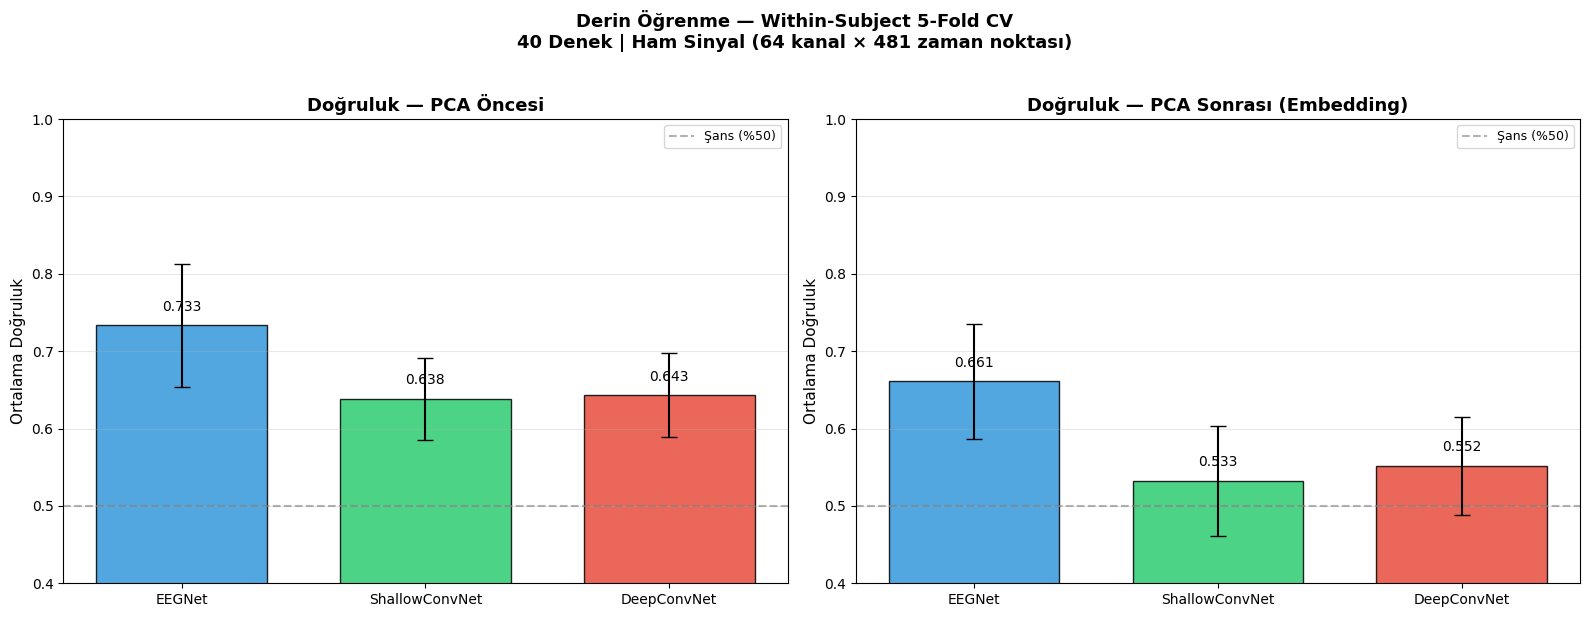

In [17]:
model_names = list(MODEL_CLASSES.keys())
x, w = np.arange(len(model_names)), 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = ['#3498db', '#2ecc71', '#e74c3c']

for ax, condition, title in zip(
    axes,
    ['no_pca', 'pca'],
    ['Doğruluk — PCA Öncesi', 'Doğruluk — PCA Sonrası (Embedding)']
):
    vals = [np.mean(all_results[n][condition]) for n in model_names]
    stds = [np.std(all_results[n][condition]) for n in model_names]
    bars = ax.bar(x, vals, w*2, yerr=stds, color=palette,
                  alpha=.85, capsize=6, edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=10)
    ax.set_ylim(0.4, 1.0)
    ax.set_ylabel('Ortalama Doğruluk', fontsize=11)
    ax.axhline(0.5, color='gray', ls='--', alpha=.6, label='Şans (%50)')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.015,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle(
    f'Derin Öğrenme — Within-Subject {N_FOLDS}-Fold CV\n'
    f'{len(subjects_X)} Denek | Ham Sinyal ({n_channels} kanal × {n_times} zaman noktası)',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('v6_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()

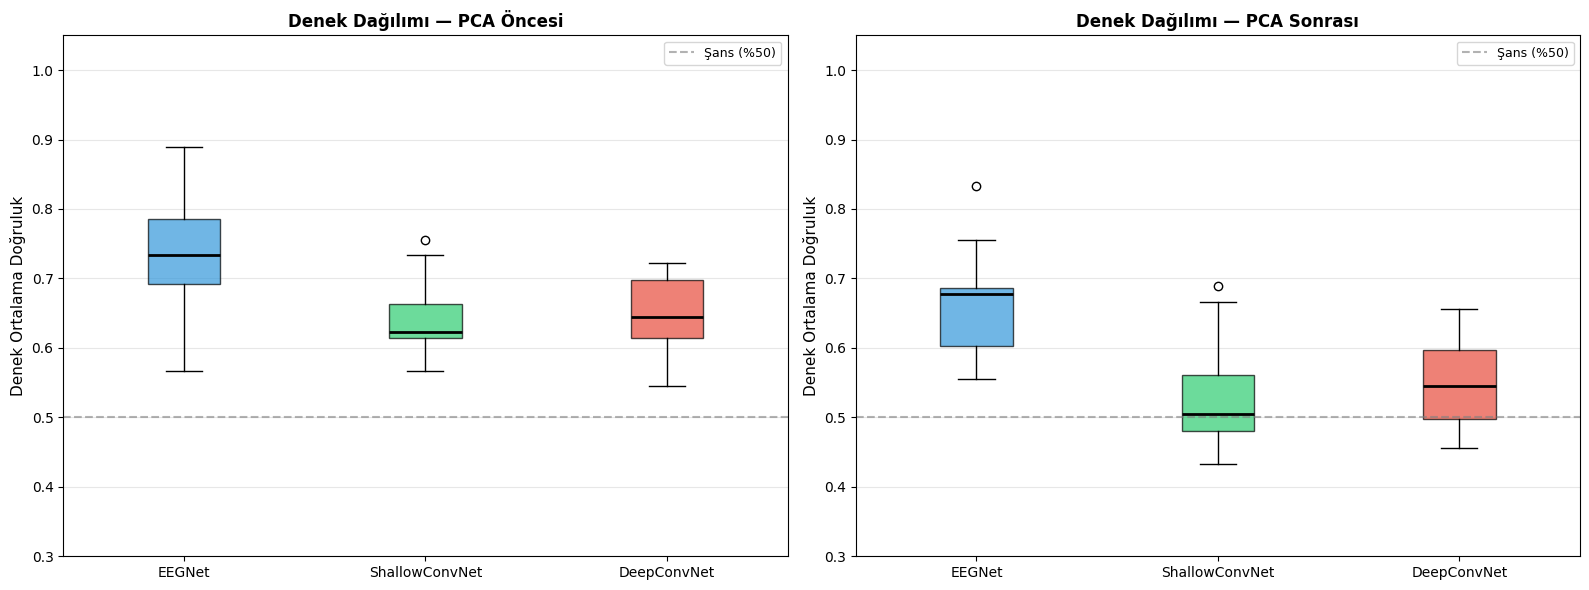

In [18]:
# Boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, condition, title in zip(
    axes,
    ['no_pca', 'pca'],
    ['Denek Dağılımı — PCA Öncesi', 'Denek Dağılımı — PCA Sonrası']
):
    data = [all_results[n][condition] for n in model_names]
    bp   = ax.boxplot(data, labels=model_names, patch_artist=True, notch=False,
                      medianprops=dict(color='black', linewidth=2))
    for patch, c in zip(bp['boxes'], palette):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Denek Ortalama Doğruluk', fontsize=11)
    ax.set_ylim(0.3, 1.05)
    ax.axhline(0.5, color='gray', ls='--', alpha=.6, label='Şans (%50)')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=.3)

plt.tight_layout()
plt.savefig('v6_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Karmaşıklık Matrisi — En İyi Model, En İyi Denek

In [19]:
# En iyi denek-model çifti
best_name_final, best_sid_final, best_acc_final = None, None, 0
for name in MODEL_CLASSES:
    for i, sid in enumerate(subjects_X.keys()):
        acc = all_results[name]['pca'][i]
        if acc > best_acc_final:
            best_acc_final  = acc
            best_name_final = name
            best_sid_final  = sid

print(f"En iyi: {best_name_final} — S{best_sid_final:03d} — doğruluk: {best_acc_final:.4f}")

X_b = subjects_X[best_sid_final]
y_b = subjects_y[best_sid_final]

X_tr_r, X_te_r, y_tr, y_te = train_test_split(
    X_b, y_b, test_size=0.25, random_state=42, stratify=y_b)
X_tr, X_te = normalize_signal(X_tr_r, X_te_r)

model_f = MODEL_CLASSES[best_name_final](n_channels, n_times).to(DEVICE)
model_f, _ = train_one_model(
    model_f, X_tr, y_tr, X_te, y_te,
    N_EPOCHS, BATCH_SIZE, LR, PATIENCE, DEVICE
)

# PCA + LR ile tahmin
emb_tr_f = get_embeddings(model_f, X_tr, DEVICE)
emb_te_f = get_embeddings(model_f, X_te, DEVICE)
n_comp_f = min(emb_tr_f.shape[1], emb_tr_f.shape[0]-1, 20)
sc_f  = StandardScaler()
pca_f = PCA(n_components=n_comp_f, random_state=42)
lr_f  = LogisticRegression(max_iter=500, random_state=42)
lr_f.fit(pca_f.fit_transform(sc_f.fit_transform(emb_tr_f)), y_tr)
y_pred_f = lr_f.predict(pca_f.transform(sc_f.transform(emb_te_f)))

print("\nSınıflandırma Raporu (PCA Sonrası):")
print(classification_report(y_te, y_pred_f,
                             target_names=['T1 (Sol El)', 'T2 (Sağ El)']))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix(y_te, y_pred_f),
    display_labels=['T1 (Sol El)', 'T2 (Sağ El)']
).plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Karmaşıklık Matrisi\n{best_name_final} — S{best_sid_final:03d}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('v6_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

IndexError: list index out of range

## 11. Nihai Özet Tablosu

In [20]:
print("\n" + "="*72)
print("NİHAİ KARŞILAŞTIRMA — DERİN ÖĞRENME (v6)")
print("="*72)
print(f"{'Model':<20} {'Koşul':<16} {'Doğruluk':>10} "
      f"{'±Std':>7} {'Medyan':>8}")
print("-"*72)

for name in MODEL_CLASSES:
    for condition, label in [('no_pca', 'PCA Öncesi'),
                              ('pca',   'PCA Sonrası')]:
        accs = np.array(all_results[name][condition])
        print(f"{name:<20} {label:<16} {accs.mean():>10.4f} "
              f"{accs.std():>7.4f} {np.median(accs):>8.4f}")
    print()

print("BOYUT AZALTMA ÖZETI:")
print(f"  Giriş : Ham EEG ({n_channels} kanal × {n_times} zaman noktası = {n_channels*n_times} değer)")
print(f"  Embedding boyutu: modele bağlı (EEGNet~16, ShallowConvNet~40+, DeepConvNet~200+)")
print(f"  PCA   : %95 varyans → önemli ölçüde küçültür")
print()
print("DEĞİŞİM (PCA öncesi → sonrası):")
for name in MODEL_CLASSES:
    d = np.mean(all_results[name]['pca']) - np.mean(all_results[name]['no_pca'])
    print(f"  {name:<20}: {np.mean(all_results[name]['no_pca']):.4f} → "
          f"{np.mean(all_results[name]['pca']):.4f}  ({d:+.4f})")


NİHAİ KARŞILAŞTIRMA — DERİN ÖĞRENME (v6)
Model                Koşul              Doğruluk    ±Std   Medyan
------------------------------------------------------------------------
EEGNet               PCA Öncesi           0.7333  0.0800   0.7333
EEGNet               PCA Sonrası          0.6611  0.0743   0.6778

ShallowConvNet       PCA Öncesi           0.6381  0.0529   0.6222
ShallowConvNet       PCA Sonrası          0.5325  0.0708   0.5056

DeepConvNet          PCA Öncesi           0.6429  0.0544   0.6444
DeepConvNet          PCA Sonrası          0.5516  0.0632   0.5444

BOYUT AZALTMA ÖZETI:
  Giriş : Ham EEG (64 kanal × 481 zaman noktası = 30784 değer)
  Embedding boyutu: modele bağlı (EEGNet~16, ShallowConvNet~40+, DeepConvNet~200+)
  PCA   : %95 varyans → önemli ölçüde küçültür

DEĞİŞİM (PCA öncesi → sonrası):
  EEGNet              : 0.7333 → 0.6611  (-0.0722)
  ShallowConvNet      : 0.6381 → 0.5325  (-0.1056)
  DeepConvNet         : 0.6429 → 0.5516  (-0.0913)


## 12. Tartışma ve Sonuç

### Klasik ML (v5) vs Derin Öğrenme (v6)

| Kriter | v5 Klasik ML | v6 Derin Öğrenme |
|---|---|---|
| Özellik mühendisliği | FBCSP (alan bilgisi gerekir) | Yok (end-to-end) |
| Veri ihtiyacı | Az (~90 epoch yeterli) | Fazla (CNN için az veri dezavantaj) |
| Yorumlanabilirlik | Yüksek (CSP filtreleri) | Düşük (kara kutu) |
| Boyut azaltma konumu | CSP sonrası (özellik seçme) | Embedding üzerinde (projeksiyon) |
| Beklenen performans | %63-72 | %58-75 (veriye bağlı) |

### Embedding Üzerinde PCA'nın Anlamı

Klasik ML'de PCA, özellik mühendisliği sonrası gürültülü özellikleri eler.
Derin öğrenmede ise PCA, ağın öğrendiği iç temsillerin **lineer ayrılabilirliğini**
test eder. İyi eğitilmiş bir modelin embedding'i PCA ile küçültüldüğünde performans
korunuyorsa, model gerçekten anlamlı ve kompakt bir temsil öğrenmiştir.

### Neden CNN Her Zaman Daha İyi Değil?

Bu veri setinde denek başına ~90-180 epoch vardır. Derin öğrenme modelleri
(özellikle DeepConvNet) yüzlerce-binlerce örnek gerektirir. Küçük veri setlerinde
kompakt modeller (EEGNet) derin modellere karşı genellikle daha iyi veya eşdeğer
performans gösterir. Bu yüzden EEGNet bu veri seti için tercih edilen modeldir.

### Klinik Önemi

Bu çalışma, EEG tabanlı **motor imgelem BCI** sisteminin otomatik sınıflandırmasını
gerçekleştirmektedir. Sol/sağ el imgelem ayrımı; ALS, inme sonrası felç gibi motor
bozukluklardan muzdarip hastaların düşünce aracılığıyla harici cihazları kontrol
etmesine olanak tanıyan nöroprotez sistemlerin temelidir.